In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Salary_dataset.csv")
df.head()


,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [ ]:
X = df[['YearsExperience']].values
y = df['Salary'].values


In [ ]:
np.random.seed(42)

indices = np.random.permutation(len(X))
train_size = int(0.7 * len(X))

train_idx = indices[:train_size]
test_idx = indices[train_size:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]


In [ ]:
from sklearn.linear_model import LinearRegression

lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

y_pred = lin_model.predict(X_test)


In [ ]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print("Linear Regression MSE:", mse)


Linear Regression MSE: 27336914.623774696


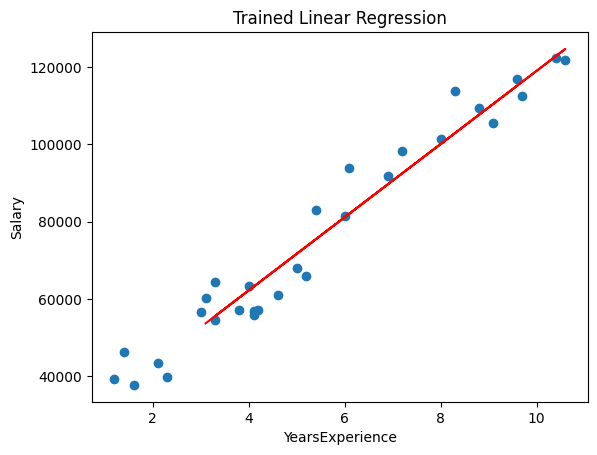

In [ ]:
plt.scatter(X, y)
plt.plot(X_test, y_pred, color='red')
plt.xlabel("YearsExperience")
plt.ylabel("Salary")
plt.title("Trained Linear Regression")
plt.show()


In [ ]:
from sklearn.utils import resample

degrees = range(1, 11)
bias_list = []
variance_list = []

n_bootstrap = 50


In [ ]:
from sklearn.preprocessing import PolynomialFeatures
for d in degrees:
    poly = PolynomialFeatures(degree=d)

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    predictions = []

    for _ in range(n_bootstrap):
        X_res, y_res = resample(X_train_poly, y_train)

        model = LinearRegression()
        model.fit(X_res, y_res)

        y_pred = model.predict(X_test_poly)
        predictions.append(y_pred)

    predictions = np.array(predictions)

    avg_pred = np.mean(predictions, axis=0)

    bias = np.mean((avg_pred - y_test) ** 2)
    variance = np.mean(np.var(predictions, axis=0))

    bias_list.append(bias)
    variance_list.append(variance)


In [ ]:
bias_variance_table = pd.DataFrame({
    "Polynomial Degree": degrees,
    "Bias^2": bias_list,
    "Variance": variance_list,
    "Total Error (Bias^2 + Variance)": np.array(bias_list) + np.array(variance_list)
})

bias_variance_table


,Polynomial Degree,Bias^2,Variance,Total Error (Bias^2 + Variance)
0,1,2.665766e+07,2.614257e+06,2.927192e+07
1,2,3.597315e+07,1.425454e+07,5.022769e+07
2,3,3.140286e+07,1.650144e+07,4.790430e+07
3,4,3.318730e+07,2.413679e+07,5.732409e+07
4,5,1.234284e+08,4.802557e+08,6.036842e+08
5,6,3.568334e+09,5.106455e+10,5.463289e+10
6,7,2.943775e+10,9.677411e+11,9.971788e+11
7,8,3.851844e+10,1.018426e+12,1.056944e+12
8,9,1.379510e+13,1.133109e+15,1.146904e+15
9,10,9.216146e+14,1.313568e+17,1.322784e+17


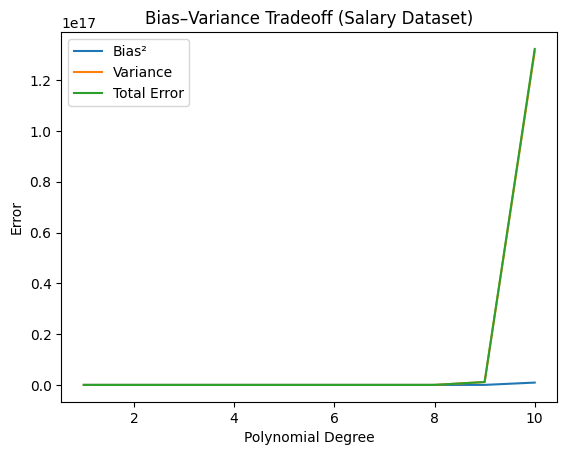

In [ ]:
plt.plot(degrees, bias_list, label="Bias²")
plt.plot(degrees, variance_list, label="Variance")
plt.plot(degrees, np.array(bias_list)+np.array(variance_list), label="Total Error")

plt.xlabel("Polynomial Degree")
plt.ylabel("Error")
plt.title("Bias–Variance Tradeoff (Salary Dataset)")
plt.legend()
plt.show()
